In [1]:
import random
from concurrent.futures import ThreadPoolExecutor

import os
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from glob import glob
from importlib import reload
from colorsys import hsv_to_rgb

import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

from models.simple_classifier import train as T, model as M, evaluation as E
from data_readers import data_loader as D, radar as R, infrared as IR, name_map as N

_=reload(D), reload(R), reload(IR), reload(N), reload(T), reload(M)

## data duration plot

In [ ]:
def measure_duration(path):
    n_frames = None
    if isinstance(path, str):
        sample = IR.InfraredData.read_from_path(path)
        n_frames = sample.n_frames
    elif isinstance(path, list):
        sample = R.RadarData.read_from_path(path)
        n_frames = sample.bin(18.7).n_frames
    else:
        print(f"Unknown path type: {type(path)}-{path}")
        return None, None
    return float(sample.timestamps[-1] - sample.timestamps[0]), n_frames

# df = D.find_available_files("../../../RF-Behavior")

# with ThreadPoolExecutor(max_workers=8) as executor:
#     infrared = list(tqdm(executor.map(measure_duration, df.infrared_path.values), total =len(df), desc="Measuring infrared"))

# with ThreadPoolExecutor(max_workers=8) as executor:
#     radar = list(tqdm(executor.map(measure_duration, df.radar_path.values), total =len(df), desc="Measuring radar"))

# df["infrared_duration"] = [x[0] for x in infrared]
# df["infrared_frame_count"] = [x[1] for x in infrared]
# df["radar_duration"] = [x[0] for x in radar]
# df["radar_frame_count"] = [x[1] for x in radar]

In [195]:
# df.to_csv("./rf_behavior_path_and_duration.csv", index=False)

df = pd.read_csv("./rf_behavior_path_and_duration.csv")
df["radar_path"] = df["radar_path"].apply(lambda x: json.loads(x.replace("'", '"')) if isinstance(x, str) else x)
df["mean_duration"] = df[["infrared_duration", "radar_duration"]].mean(axis=1)

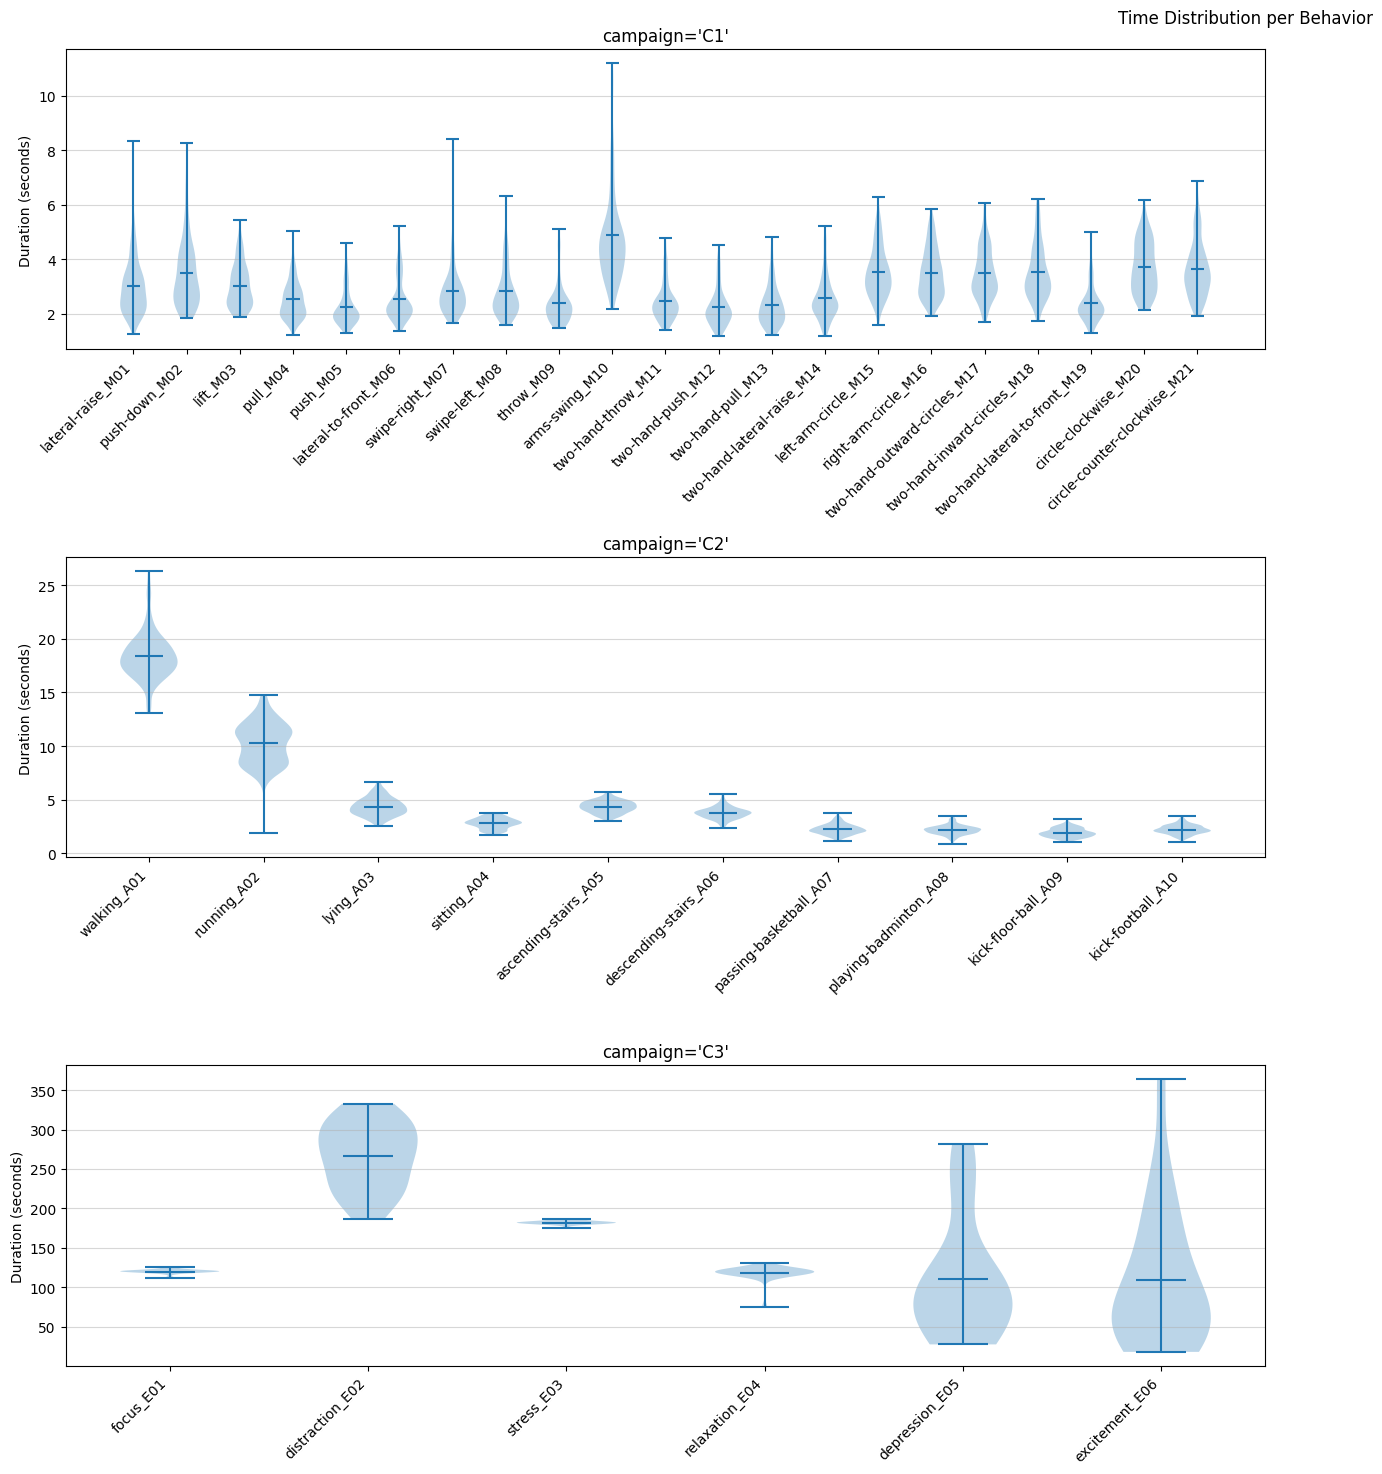

In [7]:
plt.figure(figsize=(25, 15))
sensors = ["mean", "radar", "infrared"]
plt.suptitle("Time Distribution per Behavior")
for i, campaign in enumerate(df.campaign.unique()):
    for j, sensor in enumerate(sensors[:1]):
        plt.subplot(3, 2, i*2 + j + 1)
        behaviors = df[df.campaign==campaign].behavior.unique()
        counts_per_behavior = [df[df.behavior==b][f"{sensor}_duration"].dropna() for b in behaviors]
        plt.violinplot(counts_per_behavior, showmeans=True)
        plt.title(f"{campaign=}")
        plt.xticks(ticks=range(1, len(behaviors)+1), labels=[N.map_to_name(b)+"_"+b for b in behaviors], rotation=45, ha="right")
        plt.ylabel("Duration (seconds)")
        plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

## performance against n_params

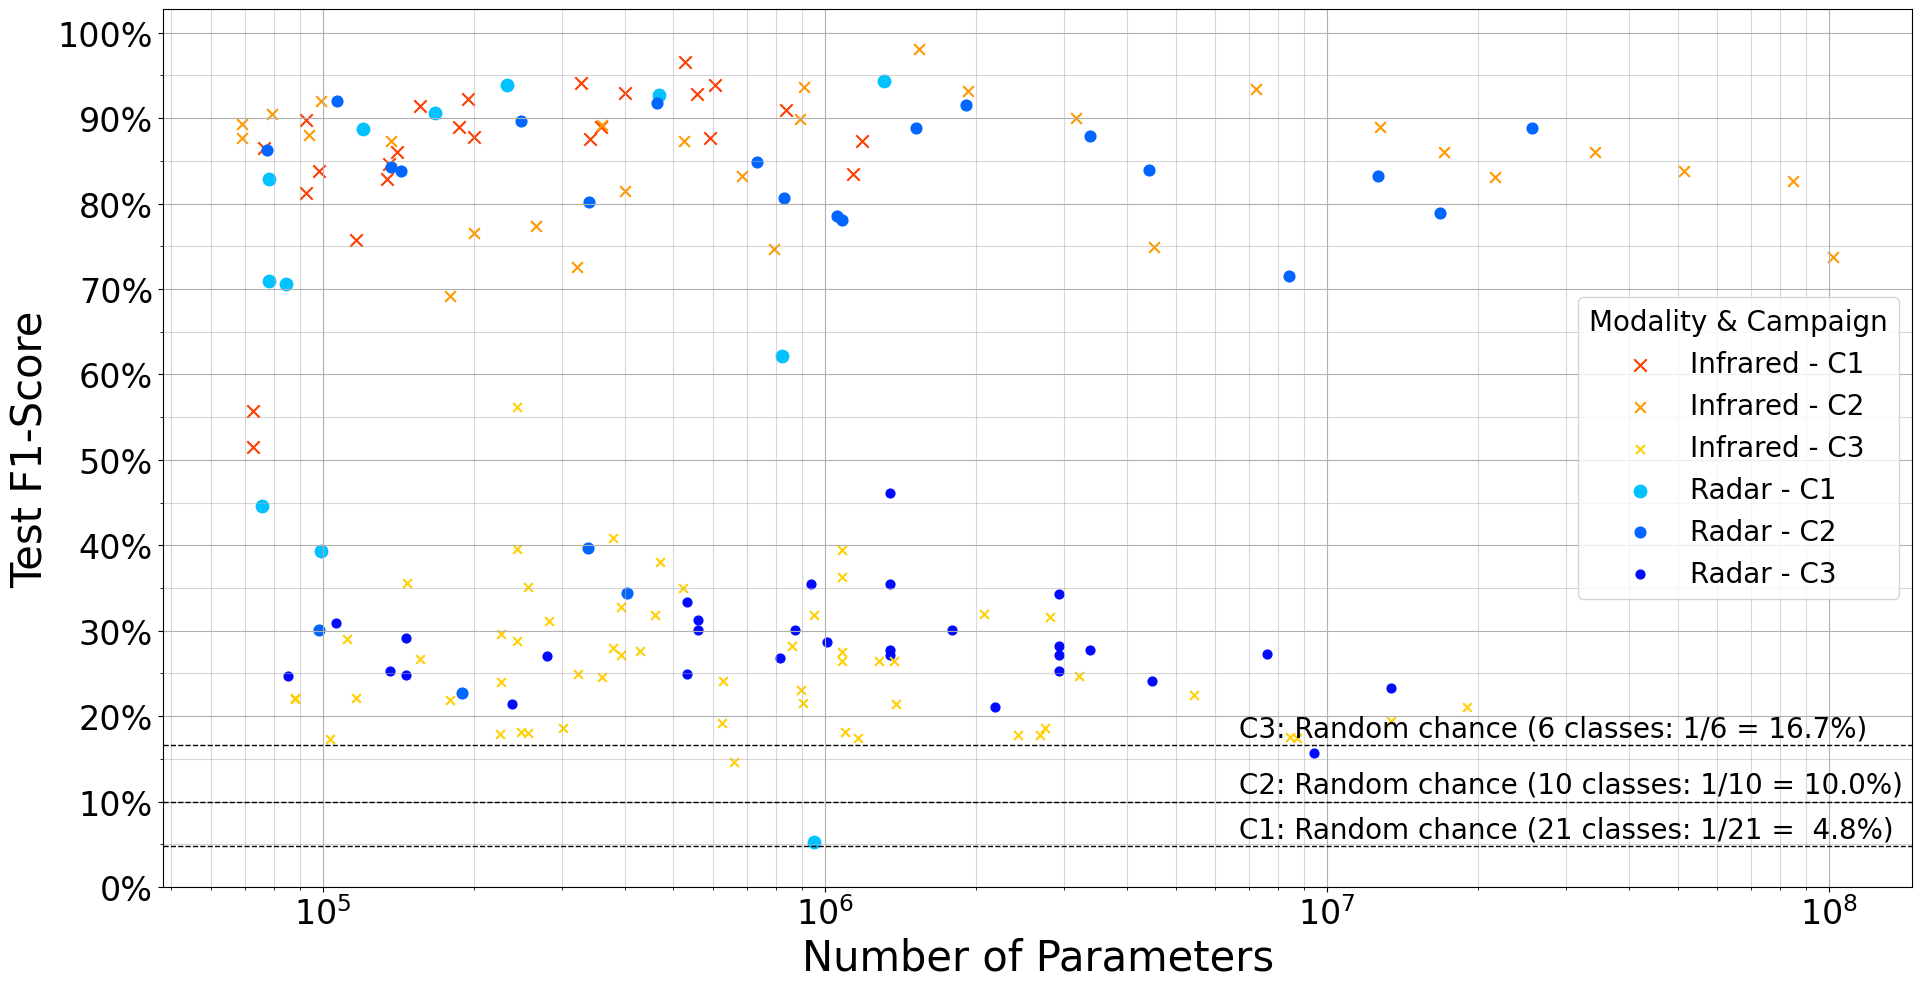

In [4]:
plt.figure(figsize=(20, 10))
for i, (n_cls, r_c, ir_c) in enumerate([(21, 0.54, 0.04), (10, 0.6, 0.10), (6, 0.66, 0.135)]):
    cls_df = pd.read_json(f"experiments/{n_cls}_class_experiment_logs.jsonl", lines=True)
    mask = cls_df["model_type"] == "radar"
    plt.scatter(cls_df[ mask]["n_params"], cls_df[ mask]["test_f1"], color=hsv_to_rgb( r_c, 1, 1), marker="o", s=40+(2-i)*20, label=f"Radar - C{i+1}")
    plt.scatter(cls_df[~mask]["n_params"], cls_df[~mask]["test_f1"], color=hsv_to_rgb(ir_c, 1, 1), marker="x", s=40+(2-i)*20, label=f"Infrared - C{i+1}")
    plt.axhline(y=1/n_cls, color="black", linestyle="--", linewidth=1)
    plt.annotate(f"C{i+1}: Random chance ({n_cls} classes: 1/{n_cls} = {1/n_cls:>5.1%})", xy=(6.7e6, 1/n_cls), xytext=(6.7e6, 1/n_cls + 0.01), color="black", fontsize=20)
    # break
plt.xlabel("Number of Parameters", fontsize=30)
plt.ylabel("Test F1-Score", fontsize=30)
yticks = np.arange(0, 1.05, 0.05)
plt.yticks(yticks, minor=True)
yticks = np.arange(0, 1.05, 0.1)
plt.yticks(yticks, labels=[f"{t:.0%}" for t in yticks], minor=False, fontsize=24)
plt.xticks(fontsize=24)
plt.xscale("log")
plt.grid(True)
plt.grid(True, which="minor", alpha=0.5)
legend = plt.legend()
handles, labels = plt.gca().get_legend_handles_labels()
handles, labels = zip(*sorted(zip(handles, labels), key=lambda x: x[1]))
legend = plt.legend(handles, labels, title="Modality & Campaign", loc="right", fontsize=20, title_fontsize=20)
# plt.title("Supervised Classification Performance of Transformer based models", fontsize=30)
plt.tight_layout()
plt.savefig("../report/figures/f1_scatter_plot.svg")
plt.show()

In [5]:
def best_model_table(n_cls_to_name, label_col, suffix ):
    paths = [f"./experiments/{n_cls}{suffix}.jsonl" for n_cls in n_cls_to_name.keys()]
    paths = [p for p in paths if os.path.exists(p)]
    exp_df = pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True).reset_index(drop=True)
    exp_df[label_col] = exp_df[label_col].apply(lambda x: tuple(x))
    exp_df["n_out" ] = exp_df[label_col].apply(len)
    best_models = exp_df.sort_values(["n_out", "model_type", "test_f1"], ascending=False).groupby(["model_type","n_out"]).head(1)
    cols = ['model_type', 'n_out', 'n_params', 'test_f1', 'train_loss', 'valid_loss', 'model_id',]
    # display(best_models[cols])
    exp_df["modality"] = exp_df["model_type"].apply(lambda x: "Radar" if x=="radar" else "Infrared")
    exp_df["campaign"] = exp_df["n_out"].apply(n_cls_to_name.get)
    group = exp_df.sort_values(["n_out", "modality", "test_f1"], ascending=False).groupby(["modality","campaign"])
    best_models = group.head(1)
    best_models = pd.merge(best_models, group.size().reset_index(name="count"), on=["modality", "campaign"])
    return (best_models[["modality", "campaign"]+cols[1:-1]+["count"]])

In [6]:
best_model_table({21: "C1", 10: "C2", 6: "C3", 31: "C1+C2", 37: "C1+C2+C3"}, "labels", "_class_experiment_logs")

,modality,campaign,n_out,n_params,test_f1,train_loss,valid_loss,count
0,Radar,C1+C2+C3,37,268453,0.837481,0.302692,0.318779,5
1,Infrared,C1+C2+C3,37,165269,0.782969,0.253531,0.368460,7
2,Radar,C1+C2,31,120895,0.895143,0.113918,0.244193,6
3,Infrared,C1+C2,31,195375,0.915257,0.038339,0.224913,5
4,Radar,C1,21,1311125,0.944120,0.161055,0.176886,12
5,Infrared,C1,21,526869,0.965628,0.061718,0.034322,25
6,Radar,C2,10,106826,0.919738,0.078454,0.248489,23
7,Infrared,C2,10,1541850,0.981166,0.024664,0.063317,29
8,Radar,C3,6,1349766,0.461190,1.177644,1.079361,30
9,Infrared,C3,6,243798,0.561636,1.082903,1.229567,56


In [7]:
best_model_table({17: "C1", 6: "C2", 23: "C1+C2", 25: "C1+C2+C3"}, "train_behaviors", "_cat_contrastive_exp_logs")

,modality,campaign,n_out,n_params,test_f1,train_loss,valid_loss,count
0,Radar,C1+C2+C3,25,817472,0.792046,0.386566,1.035338,7
1,Infrared,C1+C2+C3,25,85184,0.754154,0.895857,1.023090,7
2,Radar,C1+C2,23,175776,0.903184,0.246984,0.467637,7
3,Infrared,C1+C2,23,282176,0.881361,0.235908,0.296264,7
4,Radar,C1,17,254144,0.930375,0.225618,0.002459,6
5,Infrared,C1,17,142016,0.966812,0.407381,0.017052,7
6,Radar,C2,6,93440,0.775190,0.103729,0.146204,14
7,Infrared,C2,6,923280,0.934848,0.069871,0.119532,31


Preloading dataset:   0%|          | 0/672 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/672 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/320 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/320 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/24 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/24 [00:00<?, ?sample/s]

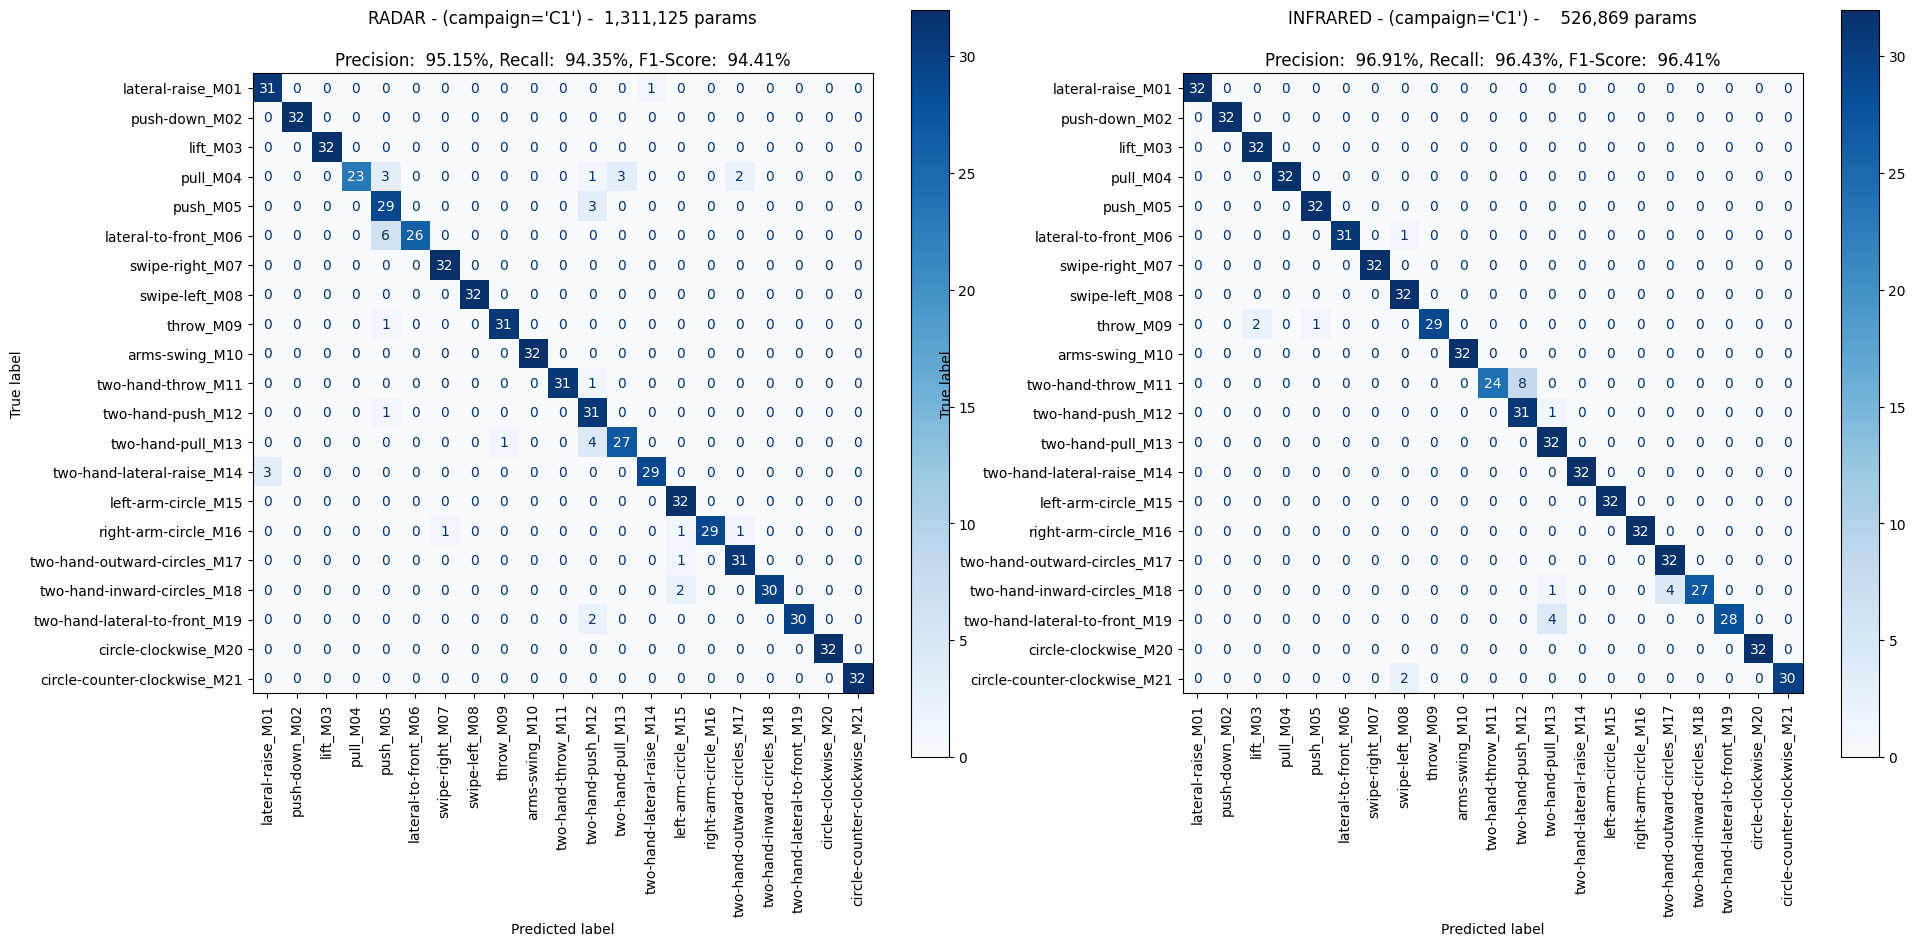

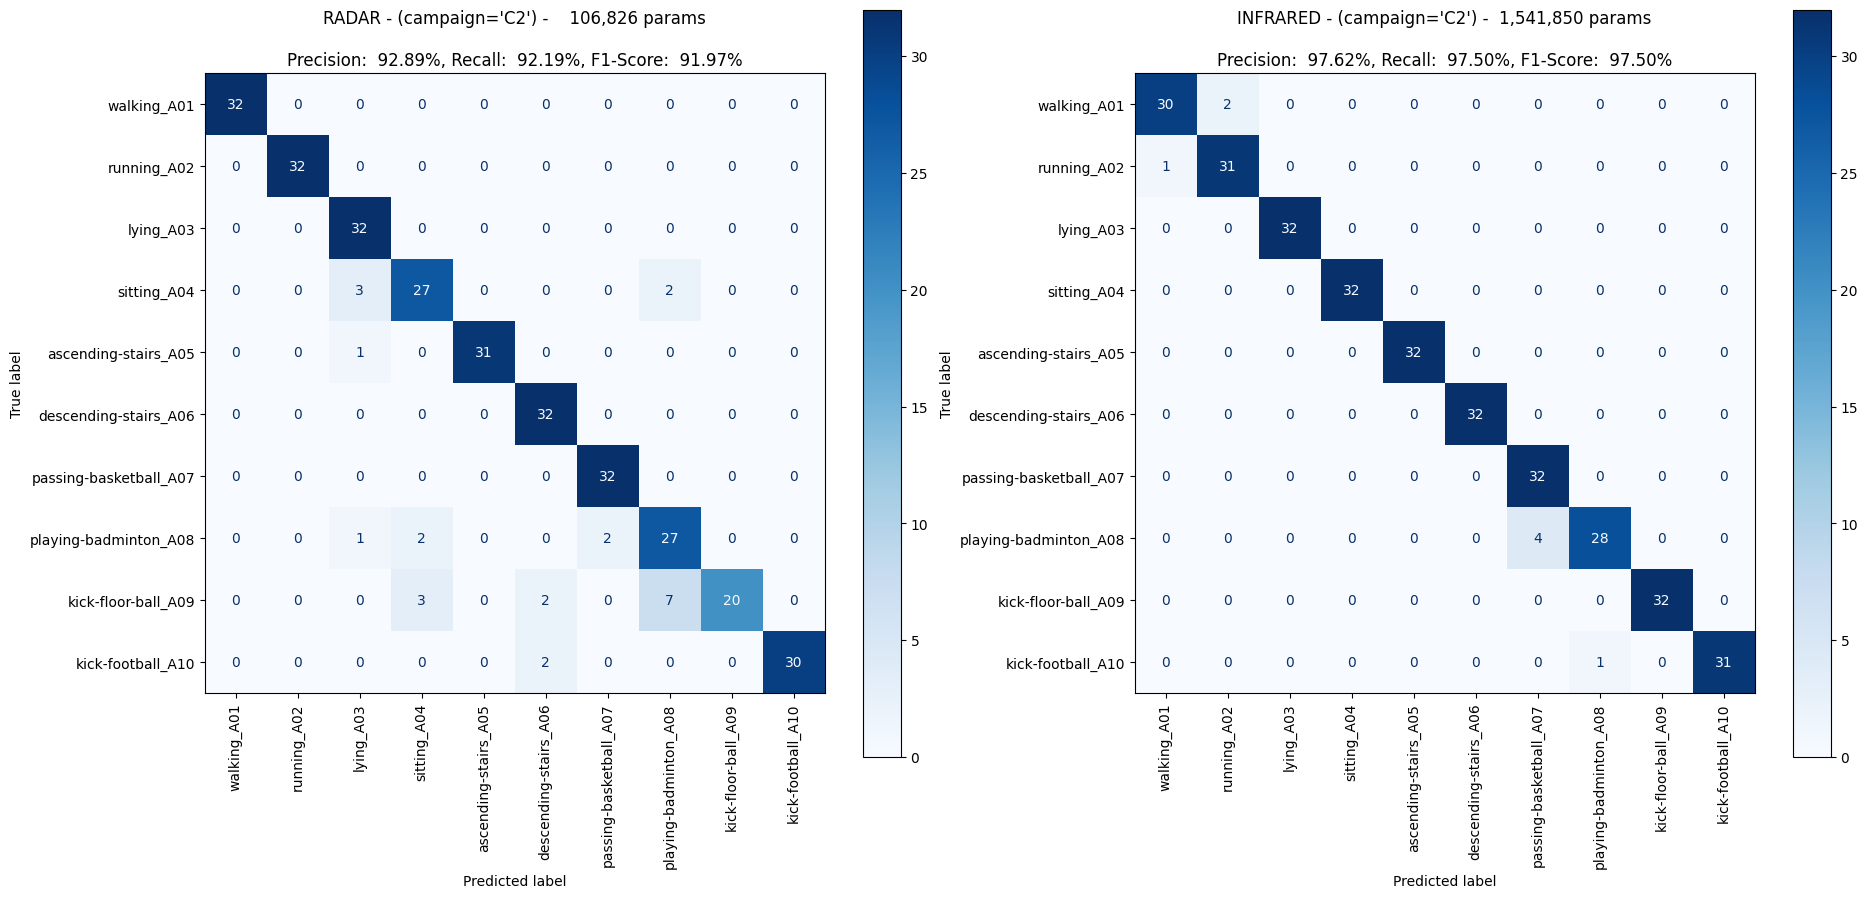

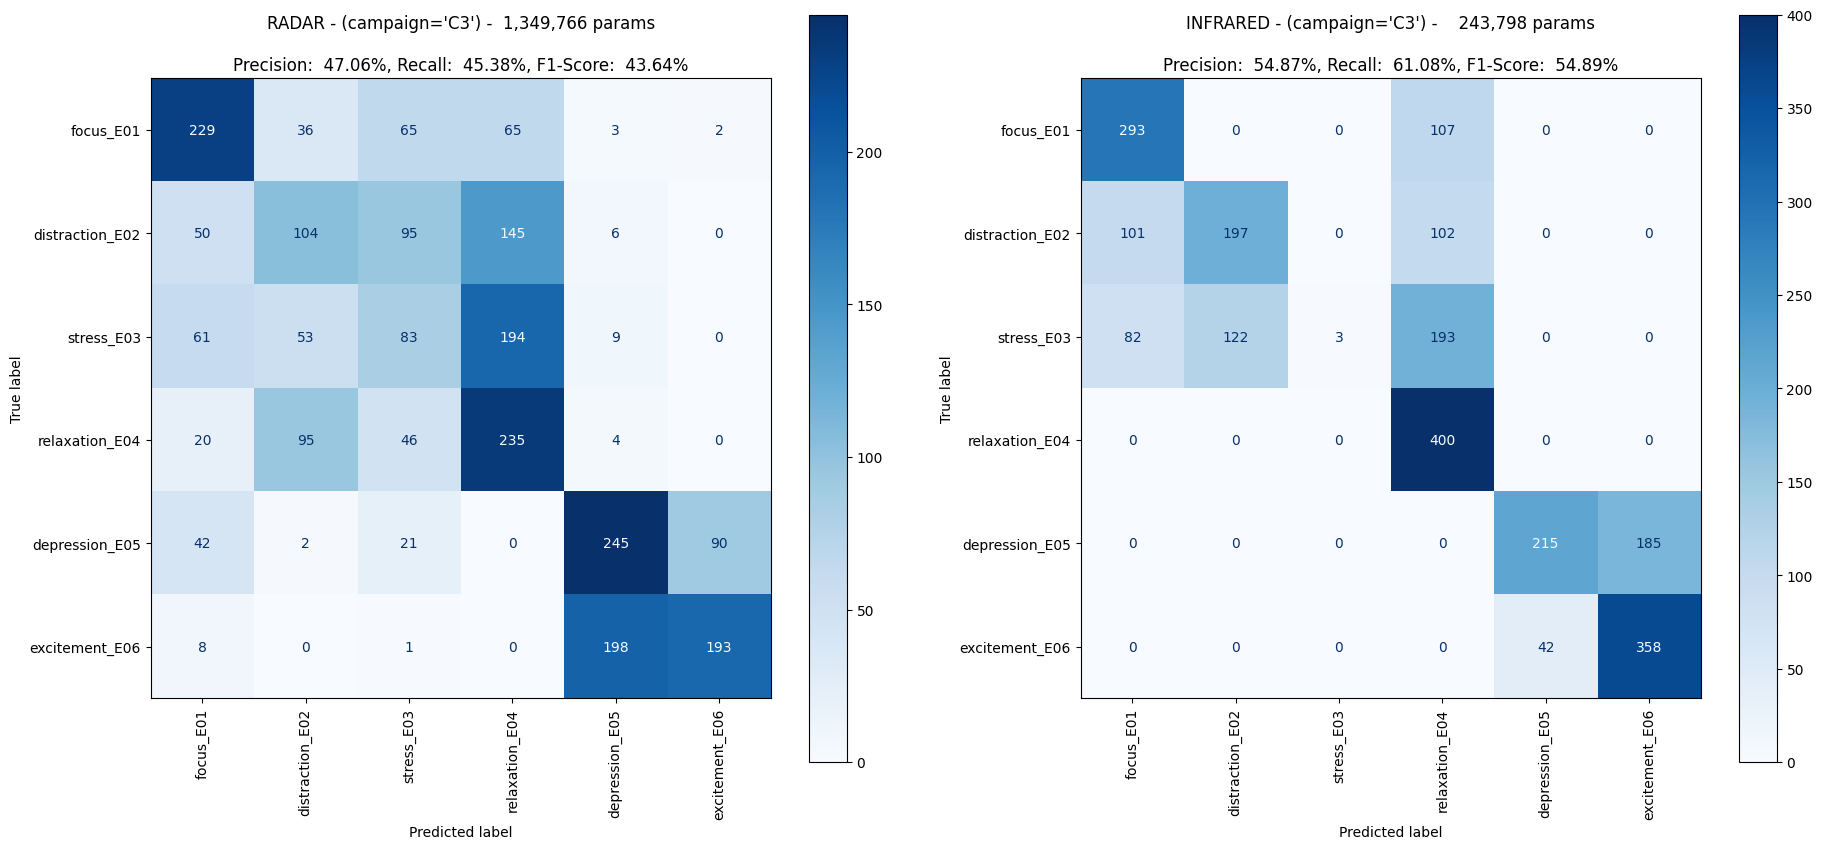

In [ ]:
data_df = D.find_available_files("../../../RF-Behavior")
# campaign, n_cls = "C3", 6
for campaign, n_cls in [("C1", 21), ("C2", 10), ("C3", 6)]: # , ("all", 37)
    df = pd.read_json(f"./experiments/{n_cls}_class_experiment_logs.jsonl", lines=True)
    mask = df["labels"].apply(lambda x: len(x) == n_cls)
    df = df[mask]
    df["modality"] = df["model_type"].apply(lambda x: x.split("_")[-1])
    best_models = df.sort_values(["modality", "test_f1"], ascending=[False, False]).groupby(["modality"]).head(1)
    plt.figure(figsize=(22, 33))
    for i, (_, row) in enumerate(best_models.iterrows()):
        model = M.get_model_from_path("experiments/"+row["model_id"]+".pt").eval().to("cuda")
        test_df = data_df[data_df.behavior.isin(row["labels"]) & (data_df.user.isin(row["test_users"]))]
        test_data = D.BehaviorDataset(test_df, modality=row["modality"]).preload()
        test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False, pin_memory=True, num_workers=0, collate_fn=D.BehaviorDataset.collate_fn)
        ys, ps, rs, f1s = {}, [], [], []
        for _ in range(100 if campaign == "C3" else 1):
            p, r, f1 = E.evaluate_classification_model(model, test_loader, device="cuda", ys=ys)
            ps.append(p)
            rs.append(r)
            f1s.append(f1)
        ax = plt.subplot(3, 2, i+1)
        disp = ConfusionMatrixDisplay.from_predictions(ys["targets"], ys["predicted"], display_labels=[N.map_to_name(b)+"_"+b for b in row["labels"]], xticks_rotation=90, cmap="Blues", ax=ax)
        disp.ax_.set_title(f"{row['model_type'].upper().split('_')[-1]} - ({campaign=}) - {row['n_params']:>10,} params\n\n"  # - test_f1={row['test_f1']:.2%}
                        f"Precision: {np.mean(ps):>7.2%}, Recall: {np.mean(rs):>7.2%}, F1-Score: {np.mean(f1s):>7.2%}")
        disp.plot()
        plt.tight_layout()
        plt.close()
plt.show()

## Unsupervised Model - Embedding Similarity

In [19]:
data_df = D.find_available_files("../../../RF-Behavior")
mask = data_df.campaign == "C3"
data_df = pd.concat(
    [data_df[~mask].reset_index(drop=True).copy()]
    + [data_df[mask].reset_index(drop=True).copy() for _ in range(8)],
    ignore_index=True,
)

exp_df = pd.read_json("./experiments/25_cat_contrastive_exp_logs.jsonl", lines=True)
row = exp_df.sort_values(["test_f1"], ascending=False).head(1).iloc[0]
model = M.get_model_from_path("experiments/"+row["model_id"]+".pt").eval().to("cuda")
embeddings_list=  []
all_labels_list = []

In [ ]:
unique_labels = []
ticks = []
for behs in ["train_behaviors", "valid_behaviors", "test_behaviors"]:
    df = data_df[data_df.behavior.isin(row[behs]) & ~data_df.filter(regex=r".*_path").isna().any(axis=1)]
    ds = D.BehaviorDataset(df.sample(frac=1), modality=row["model_type"].split("_")[-1])
    unique_labels.extend(ds.label_names)
    ticks.extend([N.map_to_name(b)+"_"+behs.split("_")[0].upper()+"_"+b for b in ds.label_names])
    loader = torch.utils.data.DataLoader(ds, batch_size=32, shuffle=False, pin_memory=True, num_workers=0, collate_fn=D.BehaviorDataset.collate_fn)
    try:
        for i, (inputs, labels) in enumerate(tqdm(loader, desc=f"Extracting embeddings for {row['model_type'].upper()} - {behs}")):
            with torch.no_grad():
                emb = model(inputs).cpu()
            embeddings_list.append(emb)
            all_labels_list.extend(np.array(ds.label_names)[labels].tolist())
    except KeyboardInterrupt as e:
        print("interrupted")
embeddings = torch.nn.functional.normalize(torch.cat(embeddings_list), p=2, dim=1)
all_labels = np.array(all_labels_list)

mean_embeddings = []
for l in unique_labels:
    mean_embeddings.append(embeddings[all_labels==l].mean(dim=0))
mean_embeddings = torch.nn.functional.normalize(torch.stack(mean_embeddings), p=2, dim=1)

# import umap
# reducer = umap.UMAP(n_components=1)
# reduced = reducer.fit_transform(mean_embeddings[:len(row["train_behaviors"])]).squeeze().tolist()
# order = np.argsort(reduced).tolist() + [len(row["train_behaviors"]) + i for i in range(len(row["valid_behaviors"]+row["test_behaviors"]))]
# ticks = np.array(ticks)[order].tolist()
# mean_embeddings = mean_embeddings[order]

sim = mean_embeddings @ mean_embeddings.T

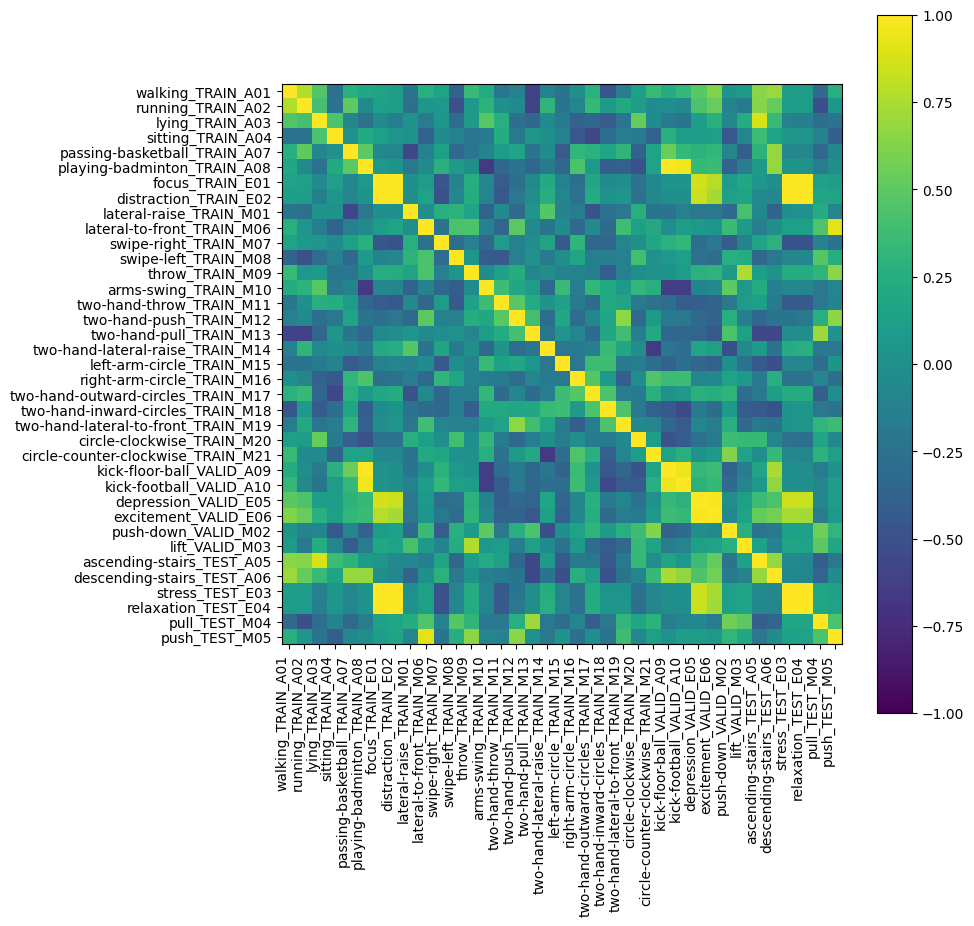

In [24]:
plt.figure(figsize=(10, 10))
plt.imshow(sim.cpu().numpy(), cmap="viridis", vmin=-1, vmax=1)
plt.xticks(ticks=range(len(ticks)), labels=ticks, rotation=90, ha="right")
plt.yticks(ticks=range(len(ticks)), labels=ticks, rotation= 0, ha="right")
plt.tight_layout()
plt.colorbar()

## augmentation

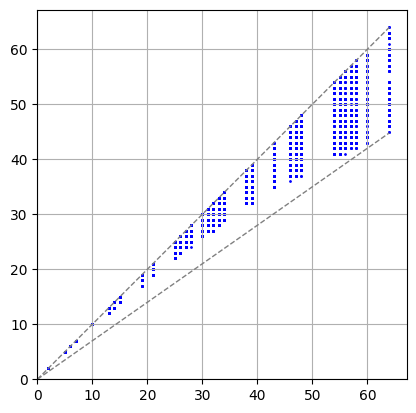

In [ ]:
sample = R.RadarData.read_from_path(glob(os.path.join(DATASET_PATH, "Radar/C1/U01/M01/01/*.pkl"))).bin(18.7)
old_lens = [len(f) for f in sample.frames]
for _ in range(100):
    new_sample = sample.augment_by_points()
    # new_sample = sample.augment_by_rid()
    new_lens = [len(f) for f in new_sample]
    plt.scatter(old_lens, new_lens, s=1, color="blue")

upper = max(max(old_lens), max(new_lens))
plt.plot([0,upper], [0,upper], color="gray", linestyle="--", linewidth=1)
plt.plot([0,upper], [0,upper*0.7], color="gray", linestyle="--", linewidth=1)
plt.xlim(0,upper*1.05)
plt.ylim(0,upper*1.05)
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')

In [78]:
# sample = R.RadarData.read_from_path(glob(os.path.join("../../../RF-Behavior", "Radar/C1/U01/M01/01/*.pkl"))).bin(18.7)
sample = IR.InfraredData.read_from_path("../../../RF-Behavior/InfraredCam/InfraredCam/C2/U01/A03/01.csv")
sample.show(azimuth=90)

(38, 6, 3)
